# Dynamic Graph Edge Weight Analysis

This notebook analyzes the edge weights (distances or similarities) of the dynamic graphs constructed using the top-k percentile approach. 

**Goal:** Understand the distribution of edge weights across all graphs in the time sequence to design an *adaptive threshold*. This threshold will act as a secondary filter to remove edges that were included by the top-k percentile but are nonetheless "too far" (for distance) or "too dissimilar" (for similarity) due to the changing scale of the graph over time.

In [6]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Configuration
Select the parameters corresponding to the dynamic graphs you want to analyze.

In [10]:
# --- Configuration ---
ITEM_ID = 907969
METRIC = "spearman"  # e.g., 'cid', 'spearman', 'euclidean'
METRIC_TYPE = "similarity"  # 'distance' (lower is better) or 'similarity' (higher is better)
WINDOW_SIZE = 15
STEP_SIZE = 1
PREFIX = "" # e.g., "", "star_", "2nddegree_", "2nddegree_star_"
PERCENTILE = 100  # Set to 100 to extract all possible combinations between the target product and others

In [ ]:
BASE_DIR = r"c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls"

# --- Configuration ---
ITEM_ID = 907969
METRIC = "spearman"  # e.g., 'cid', 'spearman', 'euclidean'
METRIC_TYPE = "similarity"  # 'distance' (lower is better) or 'similarity' (higher is better)
WINDOW_SIZE = 15
STEP_SIZE = 1
PREFIX = "" # e.g., "", "star_", "2nddegree_", "2nddegree_star_"

# Force 100 on dir labels so it creates a distinct file/folder where we keep ALL similarities
# We'll explicitly write "pct100" or similar to avoid colliding with previous filters.
dir_label = f"pctALL" 
plot_dir_name = f"{PREFIX}{dir_label}" if PREFIX else dir_label

target_dir = os.path.join(BASE_DIR, str(ITEM_ID), METRIC, str(WINDOW_SIZE), str(STEP_SIZE), plot_dir_name)
pkl_filename = f"{PREFIX}dynamic_graphs_{METRIC}_Window{WINDOW_SIZE}_Step{STEP_SIZE}_{dir_label}.pkl"

if METRIC_TYPE == "distance":
    csv_filename = pkl_filename.replace('.pkl', '_worst_distances.csv')
else:
    csv_filename = pkl_filename.replace('.pkl', '_worst_similarities.csv')

pkl_path = os.path.join(target_dir, pkl_filename)
csv_path = os.path.join(target_dir, csv_filename)

print(f"Target Pickle Path: {pkl_path}")
print(f"Target CSV Path: {csv_path}")

if not os.path.exists(pkl_path):
    print("\nPickle file does not exist. Building graphs now using your configurations...")
    import sys
    from utils import neighbourhood_graph, compute_similarities_1vsAll, compute_distances_1vsAll
    
    # 1. Load Data
    DATA_PATH = r"c:\Users\Andre Silva\Desktop\Dissertation25-26\dataset\data_andre.feather"
    print(f"Loading data from {DATA_PATH}...")
    df_raw = pd.read_feather(DATA_PATH)
    
    # Extract Category Labels
    cat_labels_dict = df_raw.drop_duplicates('item_id').set_index('item_id')['cat_label'].to_dict()
    
    # 2. Pivot to Wide format
    raw_wide = df_raw.pivot_table(index='item_id', columns='date', values='value', aggfunc='sum').fillna(0)
    
    # Use only train and val sets for building graphs
    train_size = 455
    val_size = 154
    df_wide = raw_wide.iloc[:, :train_size + val_size]
    
    enable_edges_within_star = "star" not in PREFIX
    enable_second_degree = "2nddegree" in PREFIX
    
    compute_func = compute_distances_1vsAll if METRIC_TYPE == 'distance' else compute_similarities_1vsAll
    
    # 3. Build Graphs - Note: We force percentile to 100 to get EVERYTHING
    graphs, global_threshold = neighbourhood_graph(
        product_id=ITEM_ID,
        df=df_wide,
        metric=METRIC,
        metric_type=METRIC_TYPE,
        window_size=WINDOW_SIZE,
        compute_func=compute_func,
        threshold=None,
        percentile=100,  # FORCE 100
        step_size=STEP_SIZE,
        cat_labels=cat_labels_dict,
        plot_dir=None,
        enable_edges_within_star=enable_edges_within_star,
        enable_second_degree=enable_second_degree
    )
    
    # Ensure target dir exists
    os.makedirs(target_dir, exist_ok=True)
    
    # Save the output
    print(f"\nSaving constructed graphs to {pkl_path}")
    with open(pkl_path, 'wb') as f:
        pickle.dump(graphs, f)
    print("Graphs successfully generated and saved!")
else:
    print("\nPickle file already exists. Proceeding...")

Target Pickle Path: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls\907969\spearman\15\1\pctALL\dynamic_graphs_spearman_Window15_Step1_pctALL.pkl
Target CSV Path: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls\907969\spearman\15\1\pctALL\dynamic_graphs_spearman_Window15_Step1_pctALL_worst_similarities.csv

Pickle file does not exist. Building graphs now using your configurations...
Loading data from c:\Users\Andre Silva\Desktop\Dissertation25-26\dataset\data_andre.feather...
Building 595 sliding window graphs...


## 4. Edge Weight Distribution
Let's look at the overall distribution of all edge weights to understand the global scale.

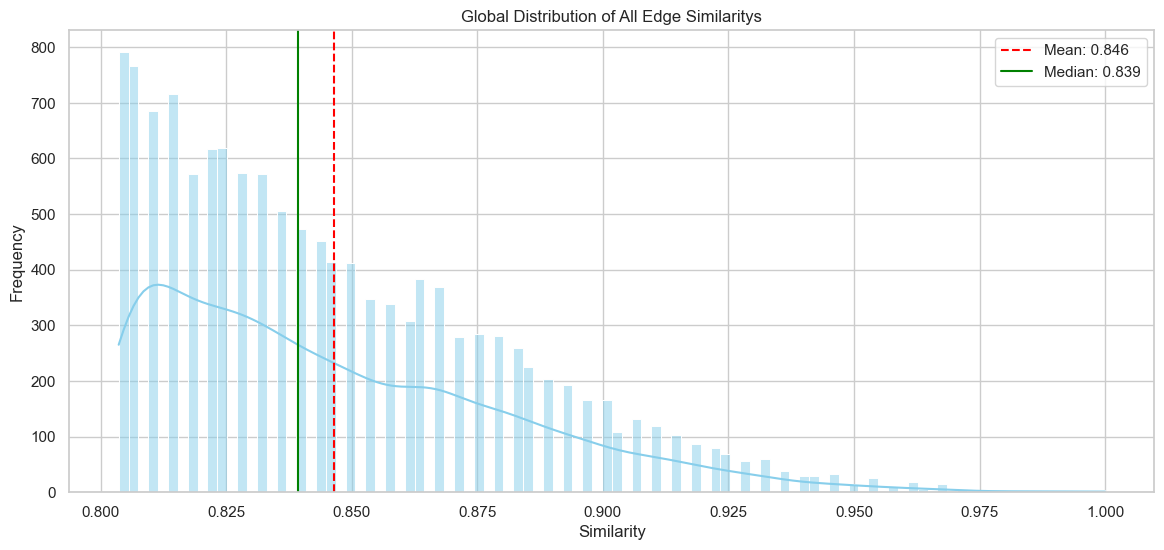

Global Percentiles:
P10: 0.8071
P25: 0.8179
P50: 0.8393
P75: 0.8679
P90: 0.8964
P95: 0.9143
P99: 0.9464


In [9]:
import pickle

# If graphs is not in memory, load it
if 'graphs' not in locals():
    with open(pkl_path, 'rb') as f:
        graphs = pickle.load(f)

# Extract all weights from all graphs
all_weights = []
for g in graphs:
    weights = [data.get('weight', 0) for u, v, data in g.edges(data=True)]
    all_weights.extend(weights)

plt.figure(figsize=(14, 6))
sns.histplot(all_weights, bins=100, kde=True, color='skyblue')
plt.title(f"Global Distribution of All Edge {METRIC_TYPE.capitalize()}s")
plt.xlabel(METRIC_TYPE.capitalize())
plt.ylabel("Frequency")
plt.axvline(np.mean(all_weights), color='red', linestyle='--', label=f'Mean: {np.mean(all_weights):.3f}')
plt.axvline(np.median(all_weights), color='green', linestyle='-', label=f'Median: {np.median(all_weights):.3f}')
plt.legend()
plt.show()

percentiles = [10, 25, 50, 75, 90, 95, 99]
print("Global Percentiles:")
for p in percentiles:
    print(f"P{p}: {np.percentile(all_weights, p):.4f}")